#### Exercise 3 - Kraftwerkseinsatzplanung

VU - Energiemodelle und Analysen

Gruppe 10 - Hannah Bennoui, Peter Geyrhofer, Johannes Tanzer, Clemens Stadler

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import gurobipy as gp
from gurobipy import GRB

In [22]:
# Import der .csv Datei und Umwandelung in pandas-dataframe

df_load = pd.read_csv('Last_PV_Wind.csv', sep=';')
df_load

,Uhrzeit,Last Winter [MW],Wind 300 MW,PV 100 MW Winter
0,01:00,720,160,0
1,02:00,680,134,0
2,03:00,640,126,0
3,04:00,620,115,0
4,05:00,620,92,0
5,06:00,660,112,0
6,07:00,940,103,2
7,08:00,1040,98,7
8,09:00,1140,139,15
9,10:00,1160,150,21


In [27]:
# Parameterdefinition

power_coal = 600 #MW
power_gud = 400 #MW
power_gas = 300 #MW
power_pumps = 200 #MW
power_PV_inst = 100 #MW
power_wind_inst = 300 #MW
power_wind = df_load['Wind 300 MW'].values
power_PV = df_load['PV 100 MW Winter'].values
eta_coal = 0.41
eta_gud = 0.58
eta_gas = 0.4
eta_turbine = 0.9
eta_pump = 0.9
fuelcost_coal = 10 #€/MWh
fuelcost_gas = 45 #€/MWh
CO2_coal = 0.35 #%
CO2_ngas = 0.2 #%
CO2_price = 80 #€/t
capacity_pumps = 600 #MWh
H_coal = 8 # MWh/t
H_ngas = 14 # MWh/t
T = 24

In [4]:
# Berechnung der Marginal Costs

mc_coal = fuelcost_coal/(eta_coal*H_coal)+(CO2_price*CO2_coal)/eta_coal
mc_gud = fuelcost_gas/(eta_gud*H_ngas)+(CO2_price*CO2_ngas)/eta_gud
mc_gas = fuelcost_gas/(eta_gas*H_ngas)+(CO2_price*CO2_ngas)/eta_gas
mc_pumps = 0
mc_PV = 0
mc_Wind = 0

print(mc_gas,mc_gud,mc_coal)

48.035714285714285 33.12807881773399 71.34146341463415


### Task 1 - Fossile Erzeugung

#### a) Kraftwerkseinsatzoptimierung

In [ ]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["GuD", "Gasturbine", "Kohle"]
n_units = 3  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [CO2_ngas, CO2_ngas, CO2_coal]
mc = [[mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit
p_max = [power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        p[i, t] = model.addVar(lb=0, ub=p_max[i], name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        # Strompreis (Schattenpreis)
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Restricted license - for non-production use only - expires 2026-11-23
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 72 columns and 72 nonzeros
Model fingerprint: 0xea8612df
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [3e+02, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 19 rows and 57 columns
Presolve time: 0.01s
Presolved: 5 rows, 15 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.1473348e+06   1.525000e+02   0.000000e+00      0s
       5    1.1655221e+06   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.165522065e+06
Stunde 0:
  GuD: 400.00 MW
  Gasturbine: 300.00 

In [6]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [7]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", df_res["CO2 (t)"].sum(), "Tonnen CO2")

Gesamtkosten: 1165522.07 €
Gesamtemissionen: 5831.0 Tonnen CO2


#### b) Grafische Darstellung der Situation

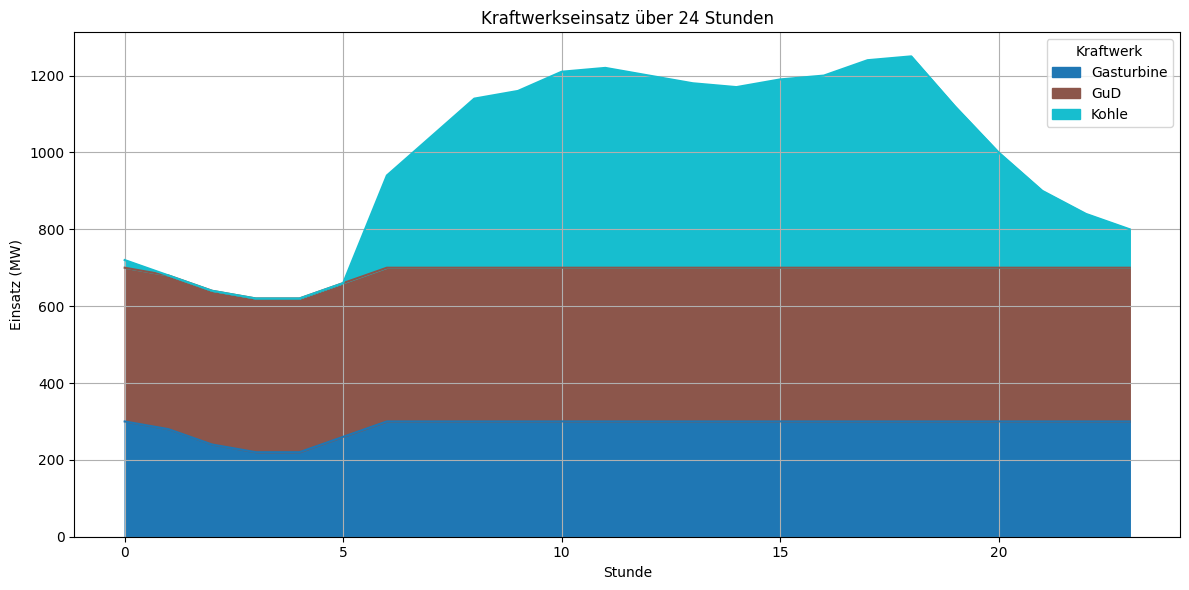

In [8]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

# Plot
df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

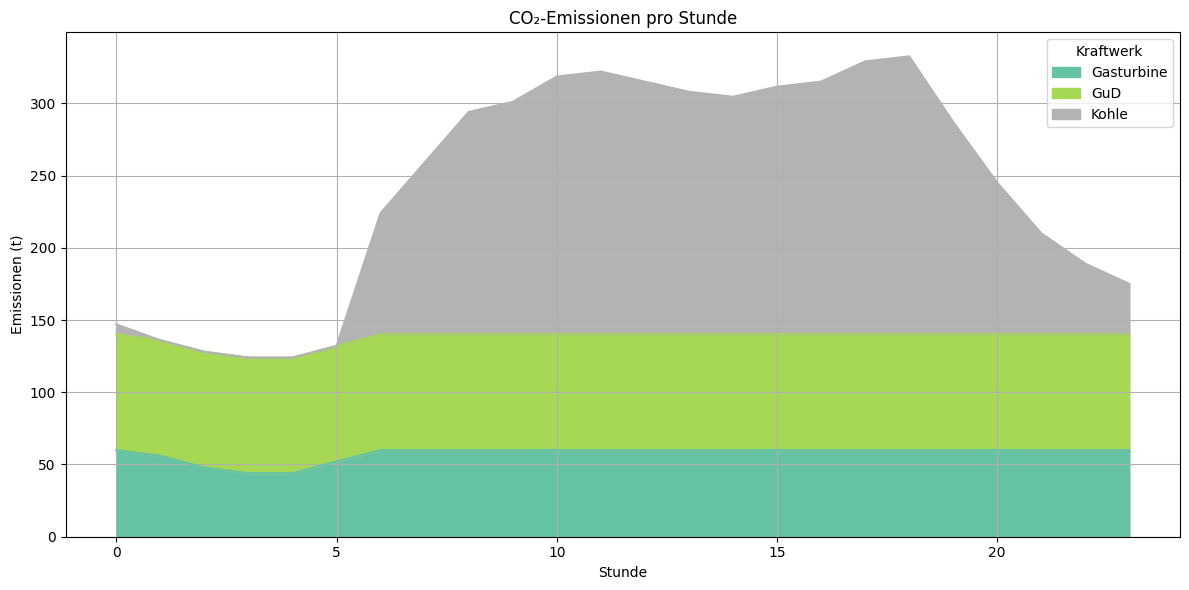

In [9]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")
df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

#### c) Interpretation der Schattenvariable

#### d) Strompreis pro Stunde

In [ ]:
df_shadow = pd.DataFrame(strompreis_liste)

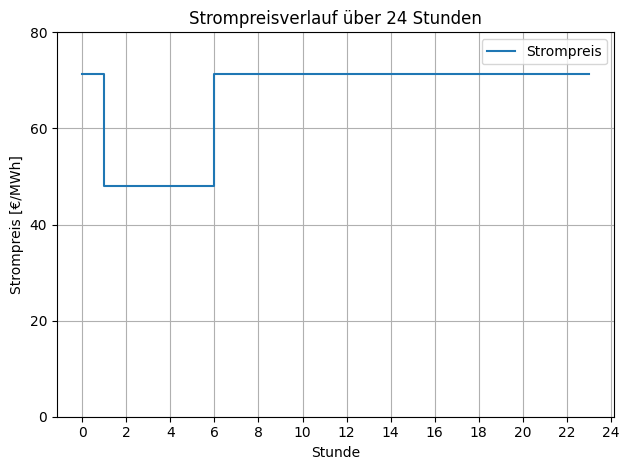

In [18]:
# Grafische Darstellung der Schattenvariable
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

### Task 2 - Erneuerbare Erzeugung

#### a) Kraftwerkseinsatzoptimierung

In [29]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_ngas, CO2_ngas, CO2_coal]
mc = [[mc_Wind]*T,[mc_PV]*T, [mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit (z.B. 100 MW)
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        # Strompreis (Schattenpreis)
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0xe0160ec2
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 16 rows and 88 columns
Presolve time: 0.01s
Presolved: 8 rows, 32 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.0350760e+05   5.667500e+02   0.000000e+00      0s
       8    9.7359709e+05   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.735970915e+05
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 160.00 MW
  Kohle: 0.00 MW
  Strompreis: 48

In [33]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [32]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", df_res["CO2 (t)"].sum(), "Tonnen CO2")

Gesamtkosten: 973597.09 €
Gesamtemissionen: 4917.45 Tonnen CO2


#### b) Grafische Darstellung der Situation

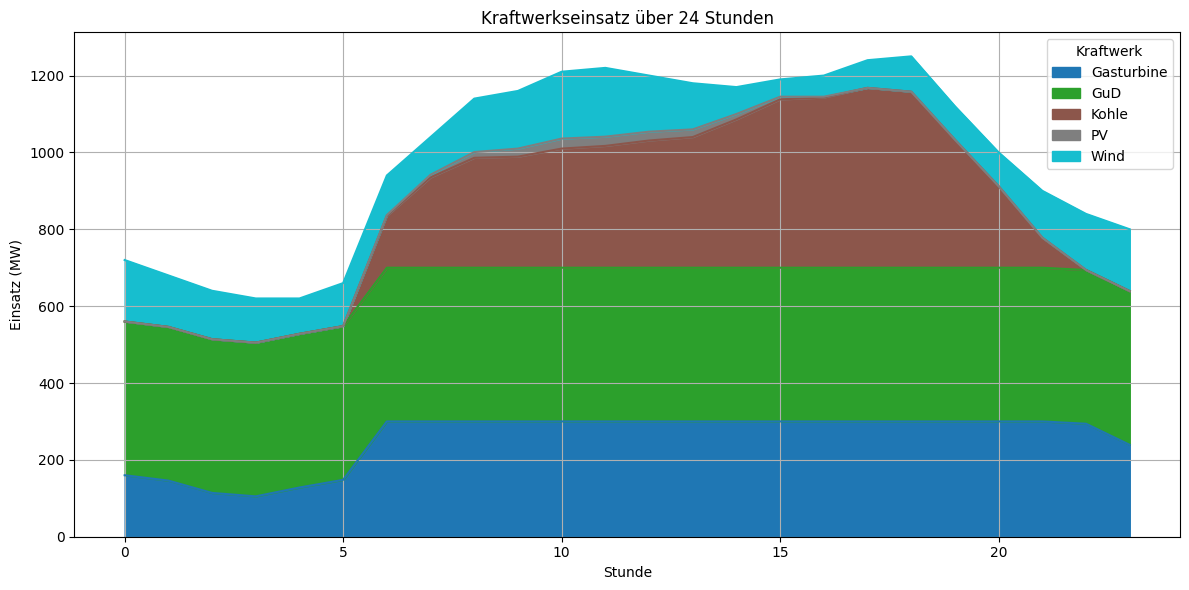

In [34]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

# Plot
df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

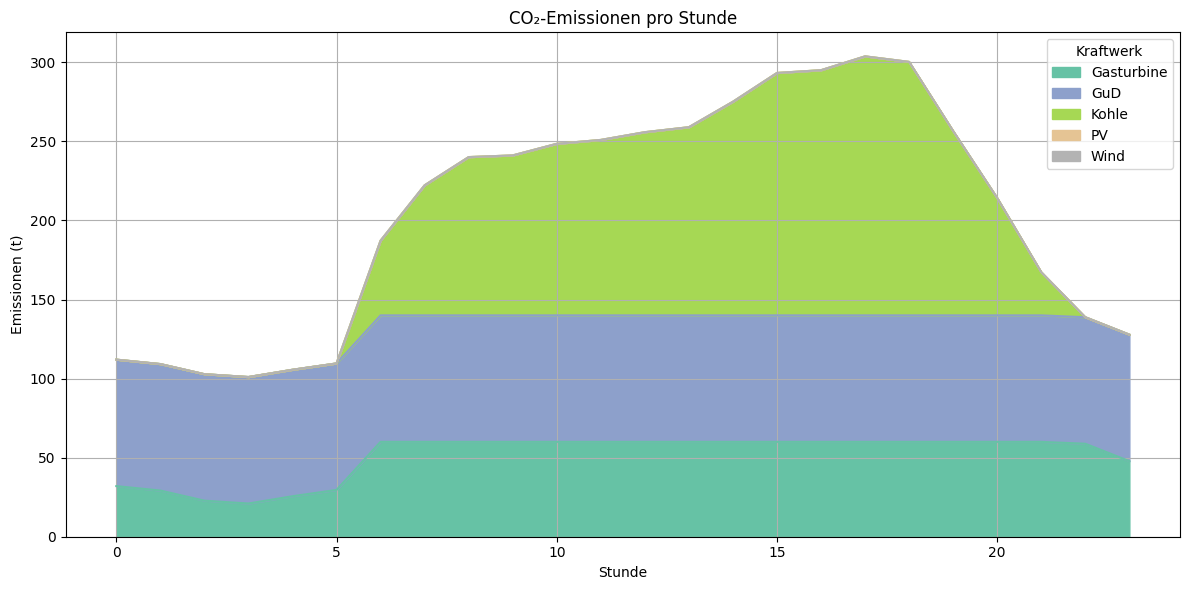

In [35]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")
df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

#### c) Strompreis pro Stunde

In [36]:
df_shadow = pd.DataFrame(strompreis_liste)

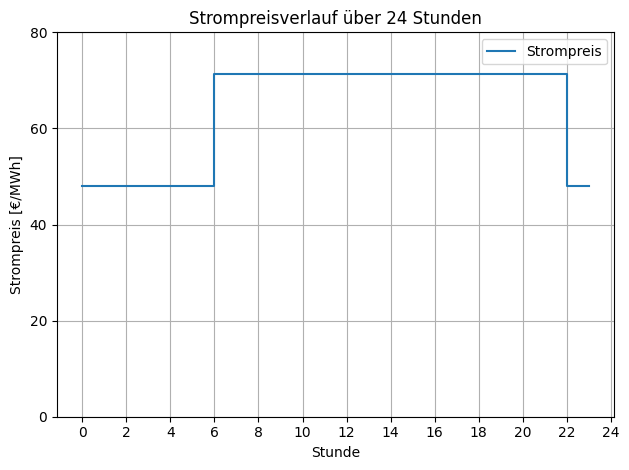

In [37]:
# Grafische Darstellung der Schattenvariable
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()